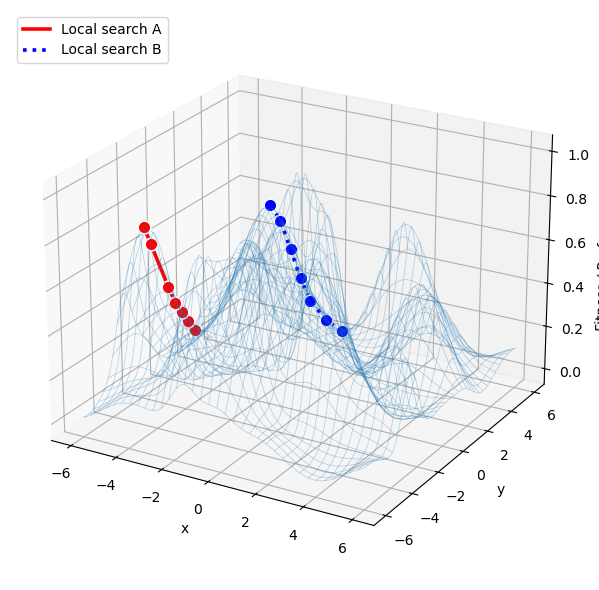

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# (A) Build a rugged 2D landscape f(x,y)
# -----------------------------
def rugged_surface(X, Y, seed=7, n_bumps=18):
    """
    Random mixture of Gaussian bumps + mild sinusoid, normalized to [0, 1].
    Produces a rugged surface on a 2D domain.
    """
    rng = np.random.default_rng(seed)

    Z = np.zeros_like(X, dtype=float)

    # Random Gaussian bumps
    for _ in range(n_bumps):
        cx, cy = rng.uniform(X.min(), X.max()), rng.uniform(Y.min(), Y.max())
        amp = rng.uniform(0.6, 1.2)
        sx, sy = rng.uniform(0.4, 1.2), rng.uniform(0.4, 1.2)
        Z += amp * np.exp(-(((X - cx) ** 2) / (2 * sx ** 2) + ((Y - cy) ** 2) / (2 * sy ** 2)))

    # Add a small periodic component for texture
    Z += 0.15 * (np.sin(1.2 * X) * np.cos(1.1 * Y))

    # Normalize to [0, 1] for nicer plotting
    Z = (Z - Z.min()) / (Z.max() - Z.min() + 1e-12)
    return Z

# Domain grid (your "2-dimensional landscape")
x = np.linspace(-6, 6, 140)
y = np.linspace(-6, 6, 140)
X, Y = np.meshgrid(x, y)
Z = rugged_surface(X, Y, seed=3, n_bumps=22)

# Helper: evaluate Z at an (x,y) by nearest grid point (discrete landscape)
def z_at(x0, y0):
    ix = np.argmin(np.abs(x - x0))
    iy = np.argmin(np.abs(y - y0))
    return Z[iy, ix]

# -----------------------------
# (B) Local search (hill-climb) that stops at a local peak
# -----------------------------
def hill_climb(start, step=0.35, max_iter=80):
    """
    Simple greedy hill-climbing on a discretized neighborhood:
    at each step, check 8 neighbors and move to the best improving one.
    Stop when no neighbor improves (local optimum).
    """
    x0, y0 = start
    path = [(x0, y0, z_at(x0, y0))]

    # 8-connected neighborhood
    nbrs = [(+1, 0), (-1, 0), (0, +1), (0, -1),
            (+1, +1), (+1, -1), (-1, +1), (-1, -1)]

    for _ in range(max_iter):
        bx, by, bz = path[-1]

        best_move = None
        best_z = bz

        for dx, dy in nbrs:
            nx, ny = bx + dx * step, by + dy * step
            # keep within domain
            if not (x.min() <= nx <= x.max() and y.min() <= ny <= y.max()):
                continue
            nz = z_at(nx, ny)
            if nz > best_z + 1e-10:
                best_z = nz
                best_move = (nx, ny, nz)

        if best_move is None:
            break
        path.append(best_move)

    return np.array(path)  # columns: x, y, z

# Two starting points -> two local trajectories
path_red  = hill_climb(start=(-4.5, -0.5), step=0.45, max_iter=60)
path_blue = hill_climb(start=(-1.0,  4.8), step=0.45, max_iter=60)

# -----------------------------
# (C) Plot: wireframe surface + two trajectories (foregrounded)
# -----------------------------
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

# 1) Draw the surface FIRST and make it visually lighter so it doesn't hide paths
ax.plot_wireframe(
    X, Y, Z,
    rstride=4, cstride=4,
    linewidth=0.55,
    alpha=0.30   # <-- key: lighten the grid
)

# 2) Lift trajectories slightly above the surface so they don't coincide with the wireframe
# If your Z is not normalized to [0,1], increase eps (e.g., eps = 0.5).
eps = 0.012
z_red  = path_red[:, 2]  + eps
z_blue = path_blue[:, 2] + eps

# 3) Plot trajectories AFTER the surface. Use larger markers + white edges.
ax.plot(path_red[:, 0], path_red[:, 1], z_red, color="red", linewidth=2.6, linestyle="-", label="Local search A")
ax.scatter(
    path_red[:, 0], path_red[:, 1], z_red,
    s=85, color="red",
    edgecolors="white", linewidths=1.2,
    depthshade=False
)

ax.plot(path_blue[:, 0], path_blue[:, 1], z_blue, color="blue", linewidth=2.6, linestyle=":", label="Local search B")
ax.scatter(
    path_blue[:, 0], path_blue[:, 1], z_blue,
    s=85, color="blue",
    edgecolors="white", linewidths=1.2,
    depthshade=False
)

# 4) Camera: rotate so trajectories are more likely on the "front" face.
# Try azim values like -30, -60, -90, 30, 60 if your paths still look hidden.
ax.view_init(elev=23, azim=-60)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Fitness / Performance")

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()